In [2]:
import pandas as pd
import requests
import datetime
import time

def get_binance_klines(symbol="BTCUSDT", interval="1h", start="2017-01-01"):# skida istorijske Bitcoin cene sa Binance API.
    """
    Download historical OHLCV data from Binance.
    interval examples: 1m, 5m, 15m, 1h, 4h, 1d
    """
    
    url = "https://api.binance.com/api/v3/klines"# endpoint za price data.
    start_ts = int(pd.Timestamp(start).timestamp() * 1000)# pretvara datum u timestamp.
    end_ts = int(time.time() * 1000)

    all_data = []

    while start_ts < end_ts:# Skida podatke u batch-evima jer API ima limit.
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ts,
            "limit": 1000  # Binance max per request
        }

        data = requests.get(url, params=params).json()

        # Stop if Binance returns empty list (end of available data)
        if not data:
            break

        all_data.extend(data)

        # Move start to last returned timestamp + 1ms
        last_time = data[-1][0]
        start_ts = last_time + 1

        # avoid hitting rate limit
        time.sleep(0.4)

    # Convert into DataFrame
    df = pd.DataFrame(all_data, columns=[
        "OpenTime", "Open", "High", "Low", "Close", "Volume",
        "CloseTime", "QuoteVolume", "Trades", "TakerBuyBase",
        "TakerBuyQuote", "Ignore"
    ])

    # Clean up
    df["OpenTime"] = pd.to_datetime(df["OpenTime"], unit="ms")
    df = df.set_index("OpenTime")

    df = df[["Open", "High", "Low", "Close", "Volume"]].astype(float)

    # Rename to match yfinance naming style
    df.index.name = "Datetime"

    return df

In [3]:
df = get_binance_klines("BTCUSDT", interval="1h", start="2017-01-01")# skida Bitcoin cenu po satu od 2017.
df.head()# prikaz prvih redova

,Open,High,Low,Close,Volume
Datetime,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


In [7]:
#!pip install ta
import ta

#return
df["return_1h"] = df["Close"].pct_change()# koliko se cena promenila u % zato što model lakše uči promene nego apsolutne cene.
df['daily_return'] = df['Close'].pct_change(24)# Dnevni prinos
#mean/std
df["rolling_mean_24h"] = df["Close"].rolling(24).mean()# prosečna cena zadnja 24h
df["rolling_std_24h"] = df["Close"].rolling(24).std()# volatilnost
#lag
df["close_lag_6h"] = df["Close"].shift(6)# cena pre 6h
df["close_lag_12h"] = df["Close"].shift(12)# cena pre 12h
df["close_lag_24h"] = df["Close"].shift(24)# cena pre 24h
df['close_lag_48h'] = df['Close'].shift(48)  # Cena pre 48h
df['close_lag_168h'] = df['Close'].shift(168)  # Cena pre 7 dana

# RSI
df['RSI_14'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()  # MACD signal linija
df['MACD_hist'] = macd.macd_diff()  # MACD histogram

# Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_mavg'] = bb.bollinger_mavg()  # Srednja Bollinger linija
df['BB_upper'] = bb.bollinger_hband()  # Gornja Bollinger linija
df['BB_lower'] = bb.bollinger_lband()  # Donja Bollinger linija

# SMA i EMA
df['SMA_20'] = ta.trend.SMAIndicator(df['Close'], window=20).sma_indicator()
df['EMA_20'] = ta.trend.EMAIndicator(df['Close'], window=20).ema_indicator()

# ATR (Average True Range)
df['ATR_14'] = ta.volatility.AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()

# ROC (Rate of Change) - Procenat promene cene u poslednjem periodu
df['ROC'] = ta.momentum.ROCIndicator(df['Close'], window=12).roc()

df["volatility_24h"] = df["return_1h"].rolling(24).std()

# za regresiju
df["price_24h"] = df["Close"].shift(-24)
df["price_48h"] = df["Close"].shift(-48)
df["price_7d"] = df["Close"].shift(-168)

df = df.dropna()# brisanje jer rolling i lag nekada stvaraju prazne vrednosti.
df.head() #ispis :)

,Open,High,Low,Close,Volume,return_1h,daily_return,rolling_mean_24h,rolling_std_24h,close_lag_6h,...,BB_upper,BB_lower,SMA_20,EMA_20,ATR_14,ROC,volatility_24h,price_24h,price_48h,price_7d
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-08-31 04:00:00,4596.54,4609.00,4586.49,4591.56,38.738009,-0.000457,0.002609,4558.581667,34.139393,4547.90,...,4626.530258,4485.945742,4556.2380,4564.230357,49.388577,0.034205,0.006230,4672.00,4794.11,4589.40
2017-08-31 05:00:00,4592.92,4628.12,4578.17,4598.54,10.514930,0.001520,0.001754,4558.917083,34.504117,4555.14,...,4625.789576,4498.340424,4562.0650,4567.497942,49.428678,-0.031739,0.006219,4664.14,4473.35,4613.94
2017-08-31 06:00:00,4600.00,4613.00,4572.99,4572.99,32.272962,-0.005556,-0.003272,4558.291667,34.087565,4569.66,...,4617.346464,4516.372536,4566.8595,4568.020995,48.755915,0.372915,0.006325,4666.66,4696.44,4674.00
2017-08-31 07:00:00,4572.99,4603.34,4572.64,4592.16,21.473024,0.004192,0.009261,4560.047500,34.722365,4574.80,...,4612.173185,4530.926815,4571.5500,4570.319948,47.466207,1.219797,0.006135,4707.50,4697.71,4710.00
2017-08-31 08:00:00,4603.58,4615.00,4578.00,4586.51,24.185580,-0.001230,0.007429,4561.456667,35.095059,4596.54,...,4613.506962,4531.244038,4572.3755,4571.861858,46.718621,0.852511,0.006143,4749.99,4628.86,4669.81


In [8]:
# -----------------------------
# 1) TEMPORAL SPLIT
# -----------------------------


# izdvajamo target
target_col = "price_24h"# za sad 24h, 48h i 7d kasnije treba za test najboljeg mozela ili bar kada uspe 24h da dobije dobar rezultat prvo


features = [
    "Open","High","Low","Close","Volume",

    "return_1h",
    "daily_return",

    "rolling_mean_24h",
    "rolling_std_24h",

    "close_lag_6h",
    "close_lag_12h",
    "close_lag_24h",
    "close_lag_48h",
    "close_lag_168h",

    "RSI_14",
    "MACD",
    "MACD_signal",
    "MACD_hist",

    "ATR_14",
    "ROC",

    "SMA_20",
    "EMA_20",
    "BB_upper",
    "BB_lower"
]

# indeks za split (60/20/20)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

#najstariji podaci idu za train, onda za vel i na kraju test
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(len(train_df), len(val_df), len(test_df))

44442 14814 14815


In [9]:
# -----------------------------
# 2) Ne koristi SCALING
# -----------------------------

In [ ]:
#!pip install xgboost

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inicijalizacija XGBoost Regressor-a
xgb_model = XGBRegressor(
    n_estimators=300,     # broj stabala
    max_depth=6,          # dubina stabala
    learning_rate=0.1,    # step size za boosting
    subsample=0.8,        # random subset za svako stablo
    colsample_bytree=0.8, # kolone po stablu
    random_state=42
)

In [11]:
# X i y za train/val/test
X_train = train_df[features].values
y_train = train_df[target_col].values

X_val = val_df[features].values
y_val = val_df[target_col].values

X_test = test_df[features].values
y_test = test_df[target_col].values

In [12]:
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 


-------------
XGBoost Regression Evaluation on Validation Set
MAE: 1619.8707 | RMSE: 2584.2707 | MAPE: 4.11% | R²: 0.9748
Mean of predictions: 34126.926
Mean of true values: 35108.60926218442
Target mean (train): 19626.004530849197
Target std (train): 17145.24238075442


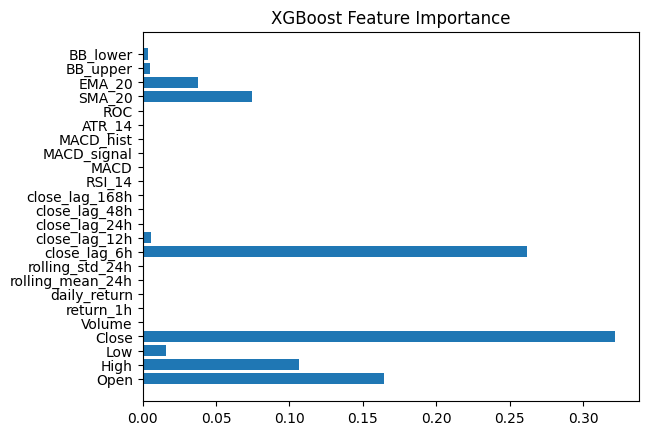

In [15]:
#!pip install matplotlib

# Predikcija na validation setu
val_preds = xgb_model.predict(X_val)
val_true = y_val

# Evaluacija
mae = mean_absolute_error(val_true, val_preds)
rmse = np.sqrt(mean_squared_error(val_true, val_preds))
r2 = r2_score(val_true, val_preds)
mape = np.mean(np.abs((val_true - val_preds) / val_true)) * 100

print("\n-------------")
print("XGBoost Regression Evaluation on Validation Set")
print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")
print("Mean of predictions:", np.mean(val_preds))
print("Mean of true values:", np.mean(val_true))
print("Target mean (train):", np.mean(y_train))
print("Target std (train):", np.std(y_train))

# Feature importance (opciono)
import matplotlib.pyplot as plt
plt.barh(features, xgb_model.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.show()